# Quality-check the output store

[`2_check_tile_status.ipynb`](2_check_tile_status.ipynb) gates the **ledger** — did every
tile × water year commit? This notebook gates the **data** those commits wrote, as five
ordered gates ending in one PASS/FAIL table.

| Gate | Question | Cost |
| --- | --- | --- |
| 1. Schema | Is this still the store `1_create_icechunk_store.ipynb` built? | metadata only |
| 2. Ledger vs data | Does every slab hold exactly what its commit claims? | 1 read per tile |
| 3. Invariants | Are the values physically possible and mutually consistent? | same read |
| 4. Composites | Do they still equal a recompute from their own annual layers? | same read |
| 5. Seams | Is a tile boundary visible in the data? | ~2 MB per edge |

Then a **regression fingerprint** of the test-tile battery and a **visual pass** on one tile.

**This is a sample, not an audit.** The gates run on the eight tiles of
[`tile_data/test_tiles_v10.txt`](tile_data/test_tiles_v10.txt) — each chosen for a failure
mode none of the others reach — plus a seeded random draw from the registry for the ordinary
interior of the fleet. Checking all ~4,400 processed tiles would cost more than the
processing run it is checking, so a passing gate means *no defect of this class in the
sample*; keeping the battery fixed is what makes that statement comparable across releases.

**Run it:** after a fleet run and before [`4_finalize_icechunk_store.ipynb`](4_finalize_icechunk_store.ipynb);
after a dependency bump, an algorithm change, or a new water year (dispatch the battery via
the workflows' `tiles_file` input first, then rerun and diff the fingerprint); after any
store migration.

The store is read **at its release tag** (`release_tag` in the config), so the gates describe
a fixed snapshot rather than a moving branch tip — during an active fleet run there is no tag
yet and it falls back to `main`, which is fine as long as you read the printed source. All
logic lives in [`global_snowmelt_runoff_onset/qc.py`](../global_snowmelt_runoff_onset/qc.py).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from global_snowmelt_runoff_onset.config import Config
from global_snowmelt_runoff_onset import qc, status
from global_snowmelt_runoff_onset.results import save_result_table

config = Config('config/global_config_v10.txt')
repo = config.open_output_repo()

# raw int16, zarr lazy indexing (no dask graph over 17M chunks)
ds_raw, session, source = qc.open_release(config)
print(f'reading {source}')

BATTERY = qc.test_tiles(config)   # tile_data/test_tiles_<version>.txt, the standing battery
N_RANDOM = 6                      # ordinary-interior sample; raise it, or change seed, to widen
SAMPLE = qc.sample_tiles(config, N_RANDOM, seed=0, exclude=BATTERY)
TILES = BATTERY + SAMPLE

commits_df = status.get_commit_records(repo)
lookup = qc.ledger_lookup(commits_df)
print(f'battery: {BATTERY}')
print(f'random:  {SAMPLE}')
print(f'{len(commits_df):,} pipeline commits in history')

SAS token is valid until 2026-08-26 19:52 UTC (308.1 hours)
----------------------------------------
Configuration loaded:
config_name = global_config_v10
version = v10
resolution = 0.00072000072000072
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 84.048
bbox_bottom = -63.4074
expected_grid_shape = 204800, 499998
expected_tile_grid = 100, 245
wy_start = 2015
wy_end = 2025
trailing_buffer_days = 120
bands = vv
mountain_snow_only = False
low_backscatter_threshold = 0.001
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
spatial_chunk_dim_zarr_output = 2048
inner_chunk_dim = 256
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow_v10.geojson
snow_phenology_zarr_store_azure_path = snowmelt/modis_snow_phenology/modis_snow_phenology_v1
global_runoff_icechunk_azure_prefix = snowmelt/snowmelt_runoff_onset/global_runoff_onset_v10
release_tag = v10.0
global_runo

## Gate 1 — schema

Metadata only, no chunk reads. The damage this catches is total: a wrong zarr `fill_value`
makes every never-written region (ocean, empty years, unprocessed tiles) decode as a valid
0.0 instead of nodata, and a changed shard geometry silently destroys the
one-shard-per-tile-year write isolation every concurrent fleet writer depends on.

In [2]:
schema_df = qc.check_schema(config, ds_raw, session)
failed = schema_df[~schema_df.ok]
print(f'{len(failed)} of {len(schema_df)} checks failed')
display(failed if len(failed) else schema_df.head(8))

0 of 40 checks failed


,check,expected,actual,ok
0,runoff_onset: shape,"(11, 204800, 499998)","(11, 204800, 499998)",True
1,runoff_onset: dtype,int16,int16,True
2,runoff_onset: zarr fill_value,-9999,-9999,True
3,runoff_onset: _FillValue attr,-9999,-9999,True
4,runoff_onset: shards,"(1, 2048, 2048)","(1, 2048, 2048)",True
5,runoff_onset: chunks,"(1, 256, 256)","(1, 256, 256)",True
6,runoff_onset: scale_factor,1.0,1.0,True
7,temporal_resolution: shape,"(11, 204800, 499998)","(11, 204800, 499998)",True


## Gates 2–4 — one read per tile

Each tile is read once, raw (int16, ~210 MB for a full tile), and three gates run off it:

- **Ledger vs data.** The commit stats already record `valid_px` per tile-year, so this is an
  *equality* test, not a tolerance: a `data` commit must find exactly that many valid pixels
  in its slab, and an `empty` marker — or no commit at all — must find a slab that was never
  written. This is the only check that can catch a durably-wrong empty marker (the hemisphere
  trap in [`README.md`](README.md), where an all-fill phenology slab is indistinguishable
  from verified no-snow) or a region write that landed on the wrong shard.
- **Invariants.** DOWY in range, MAD non-negative, temporal resolution positive, and
  `runoff_onset` valid ⇒ `temporal_resolution` valid. That implication is deliberately
  one-directional: tr is search-window-length / valid-acquisition-count, so any pixel with an
  onset estimate must have one, but a pixel can have acquisitions and still yield no
  qualifying backscatter minimum.
- **Composites.** Recomputed from the tile's own annual layers by the same
  `processing.median_*_with_min_obs` the pipeline called, required to have an identical nodata
  mask — which is also the `min_years_for_median_std` rule — and to agree within the int16
  quantization. That tolerance carries **two** terms: half a step for the composite's own
  rounding, plus half a step for the source's, because the pipeline reduced the annual layers
  while they were still float32 in memory whereas this recompute starts from what the store
  holds. The second term only bites `temporal_resolution_median` (0.05 + 0.05 = 0.1), the one
  composite whose source variable is scaled — `runoff_onset` stores integer DOWY exactly.
  Measured against v10.0, ~0.01% of pixels on some tiles land at exactly one 0.1 step.
  Catches a **stale** composite (written before a later single-year reprocess) directly, where
  `status.py` can only infer staleness from commit ordering — and a stale one is off by days,
  far outside either tolerance.

In [3]:
ledger, invariants, composites, prints = [], [], [], []
battery_set = set(BATTERY)

for row, col in TILES:
    tile = qc.load_tile(config, ds_raw, row, col)
    ledger.append(qc.check_ledger(tile, lookup))
    invariants.append(qc.check_invariants(tile))
    composites.append(qc.check_composites(tile, config))
    if (row, col) in battery_set:
        prints.append(qc.fingerprint(tile))   # the baseline is the fixed battery only
    print(f'({row},{col}) checked')
    del tile

ledger_df = pd.concat(ledger, ignore_index=True)
invariants_df = pd.concat(invariants, ignore_index=True)
composites_df = pd.concat(composites, ignore_index=True)
fingerprint_df = pd.concat(prints, ignore_index=True)

(10,0) checked
(9,138) checked
(25,39) checked
(28,65) checked
(25,190) checked
(80,240) checked
(56,69) checked
(57,69) checked
(9,35) checked
(19,60) checked
(25,185) checked
(27,209) checked
(34,177) checked
(65,73) checked


In [4]:
for name, frame in (('ledger vs data', ledger_df), ('invariants', invariants_df),
                    ('composites', composites_df)):
    failed = frame[~frame.ok]
    print(f'\n=== {name}: {len(failed)} of {len(frame)} checks failed ===')
    display(failed if len(failed) else frame.head(6))

# what the sample actually contained, so a clean gate isn't misread as a no-op
print('\nsampled tile-years by ledger status:')
display(ledger_df.groupby(['ledger_status', 'empty_reason'], dropna=False)
        .agg(n=('ok', 'size'), store_px=('store_valid_px', 'sum')))


=== ledger vs data: 0 of 168 checks failed ===


,tile,row,col,water_year,ledger_status,empty_reason,ledger_valid_px,store_valid_px,ok,note
0,"(10,0)",10,0,2015,data,NaN,974.0,974,True,
1,"(10,0)",10,0,2016,data,NaN,153.0,153,True,
2,"(10,0)",10,0,2017,data,NaN,2747469.0,2747469,True,
3,"(10,0)",10,0,2018,data,NaN,2746875.0,2746875,True,
4,"(10,0)",10,0,2019,data,NaN,2735141.0,2735141,True,
5,"(10,0)",10,0,2020,data,NaN,2741418.0,2741418,True,



=== invariants: 0 of 84 checks failed ===


,tile,row,col,check,n_violations,ok
0,"(10,0)",10,0,"runoff_onset in [1,366]",0,True
1,"(10,0)",10,0,"runoff_onset_median in [1,366]",0,True
2,"(10,0)",10,0,runoff_onset_mad >= 0,0,True
3,"(10,0)",10,0,"temporal_resolution in (0,400]",0,True
4,"(10,0)",10,0,"temporal_resolution_median in (0,400]",0,True
5,"(10,0)",10,0,runoff_onset valid => temporal_resolution valid,0,True



=== composites: 0 of 42 checks failed ===


,tile,row,col,variable,n_compared,n_nodata_mismatch,n_over_tolerance,max_absdiff,tolerance,ok
0,"(10,0)",10,0,runoff_onset_median,2742257,0,0,0.50,0.501,True
1,"(10,0)",10,0,runoff_onset_mad,2742257,0,0,0.00,0.051,True
2,"(10,0)",10,0,temporal_resolution_median,2742257,0,0,0.05,0.101,True
3,"(9,138)",9,138,runoff_onset_median,3844372,0,0,0.50,0.501,True
4,"(9,138)",9,138,runoff_onset_mad,3844372,0,0,0.00,0.051,True
5,"(9,138)",9,138,temporal_resolution_median,3844372,0,0,0.05,0.101,True



sampled tile-years by ledger status:


n   store_px
ledger_status empty_reason                    
data          NaN               154  224793902
empty         no_s1_data          4          0
              no_seasonal_snow    8          0
              no_valid_pixels     2          0

## Gate 5 — tile seams

Tiles are processed as independent jobs, so a visible seam is the signature failure of the
whole architecture — and nothing else in the pipeline looks for one. For each internal
boundary of the sampled tiles this compares the median |difference| of the pixel pairs
straddling it against the median |difference| of the pairs one pixel in on either side. A
ratio near 1 means the boundary is invisible in the data; a large ratio localizes the seam.

Reads four pixel-wide strips per edge, not whole tiles. This is also the evidence the
deferred *"weighted mean cascade in the pyramid, only if QC finds edge artifacts"* decision
currently lacks.

In [5]:
seams_df = qc.check_seams(config, ds_raw, TILES)   # runoff_onset_median, max_ratio=1.5
print(f'{(~seams_df.ok).sum()} of {len(seams_df)} edges over the ratio threshold')
display(seams_df.sort_values('ratio', ascending=False).head(10))

0 of 28 edges over the ratio threshold


,tile,edge,n_pairs,across_median,inside_median,ratio,ok,note
2,"(9,138)",right,1837,3.0,2.0,1.500000,True,
3,"(9,138)",bottom,2048,4.0,3.0,1.333333,True,
1,"(10,0)",bottom,1733,6.0,6.0,1.000000,True,
4,"(25,39)",right,1768,5.0,5.0,1.000000,True,
17,"(9,35)",bottom,2048,3.0,3.0,1.000000,True,
18,"(19,60)",right,1927,6.0,6.0,1.000000,True,
19,"(19,60)",bottom,2000,8.0,8.0,1.000000,True,
20,"(25,185)",right,1107,6.0,6.0,1.000000,True,
22,"(27,209)",right,1897,5.0,5.0,1.000000,True,
21,"(25,185)",bottom,2048,10.0,10.0,1.000000,True,


## Regression fingerprint of the battery

What replaces "diff against v9" as the regression mechanism. v9 is a frozen historical store
that v10 is *expected* to differ from for documented reasons (see the appendix), so that diff
has no failing value; a fingerprint of the current release does. Per battery tile × water
year: valid pixel count, DOWY percentiles, median temporal resolution, and a hash of the raw
stored bytes — the hash says *whether* anything changed, the statistics say *how*.

First run writes the baseline. Later runs diff against it, and overwriting is deliberate
(`BLESS_BASELINE`) so a regression can't quietly become the new normal.

In [6]:
BLESS_BASELINE = False   # True to adopt this run as the new baseline
baseline_path = Path('results') / config.version / 'qc_test_tile_fingerprint.csv'

if baseline_path.exists():
    fingerprint_diff = qc.compare_fingerprints(fingerprint_df, pd.read_csv(baseline_path))
    changed = fingerprint_diff[~fingerprint_diff.ok]
    print(f'{len(changed)} of {len(fingerprint_diff)} battery tile-years changed')
    display(changed if len(changed) else fingerprint_diff.head(6))
else:
    fingerprint_diff = pd.DataFrame({'ok': pd.Series(dtype=bool)})
    print(f'no baseline at {baseline_path} — writing this run as the baseline')
    BLESS_BASELINE = True

if BLESS_BASELINE:
    save_result_table(fingerprint_df, 'qc_test_tile_fingerprint',
                      version=config.version, results_dir='results')

0 of 96 battery tile-years changed


,row,col,water_year,ok,note,valid_px,d_valid_px,d_p50_dowy,d_median_tr_days,hash16,hash16_baseline
0,9,138,2015,True,,3810660,0,0.0,0.0,d89881b60b49482b,d89881b60b49482b
1,9,138,2016,True,,3811816,0,0.0,0.0,a9eddd617c253597,a9eddd617c253597
2,9,138,2017,True,,3822358,0,0.0,0.0,47eefb97e3baa859,47eefb97e3baa859
3,9,138,2018,True,,3822616,0,0.0,0.0,1015aed6be8152b6,1015aed6be8152b6
4,9,138,2019,True,,3812121,0,0.0,0.0,eeccf2dd52be4ca3,eeccf2dd52be4ca3
5,9,138,2020,True,,3832665,0,0.0,0.0,2dd1c620db466962,2dd1c620db466962


## Visual pass

The gates prove the store is internally consistent; they cannot tell you the pattern is
wrong. Composites over a basemap (UTM, so shapes aren't distorted at latitude), then per-year
onset, per-year **anomaly** — where a single bad year shows up, invisible in the absolute
field — and per-year temporal resolution. Styling comes from `plot_utils.variable_kw`, so
these panels are directly comparable to the manuscript figures.

Swap in any tile from `TILES`; the battery tiles are the interesting ones (antimeridian,
scene-densest, empty-year mixes, the equator-straddling Cayambe pair).

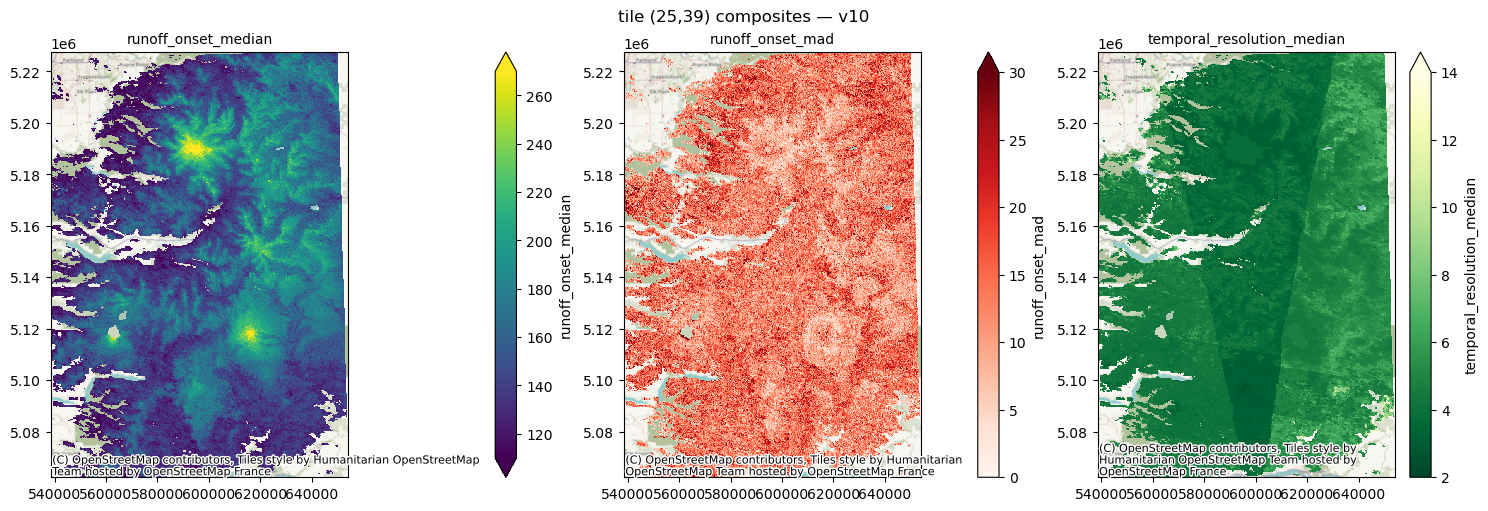

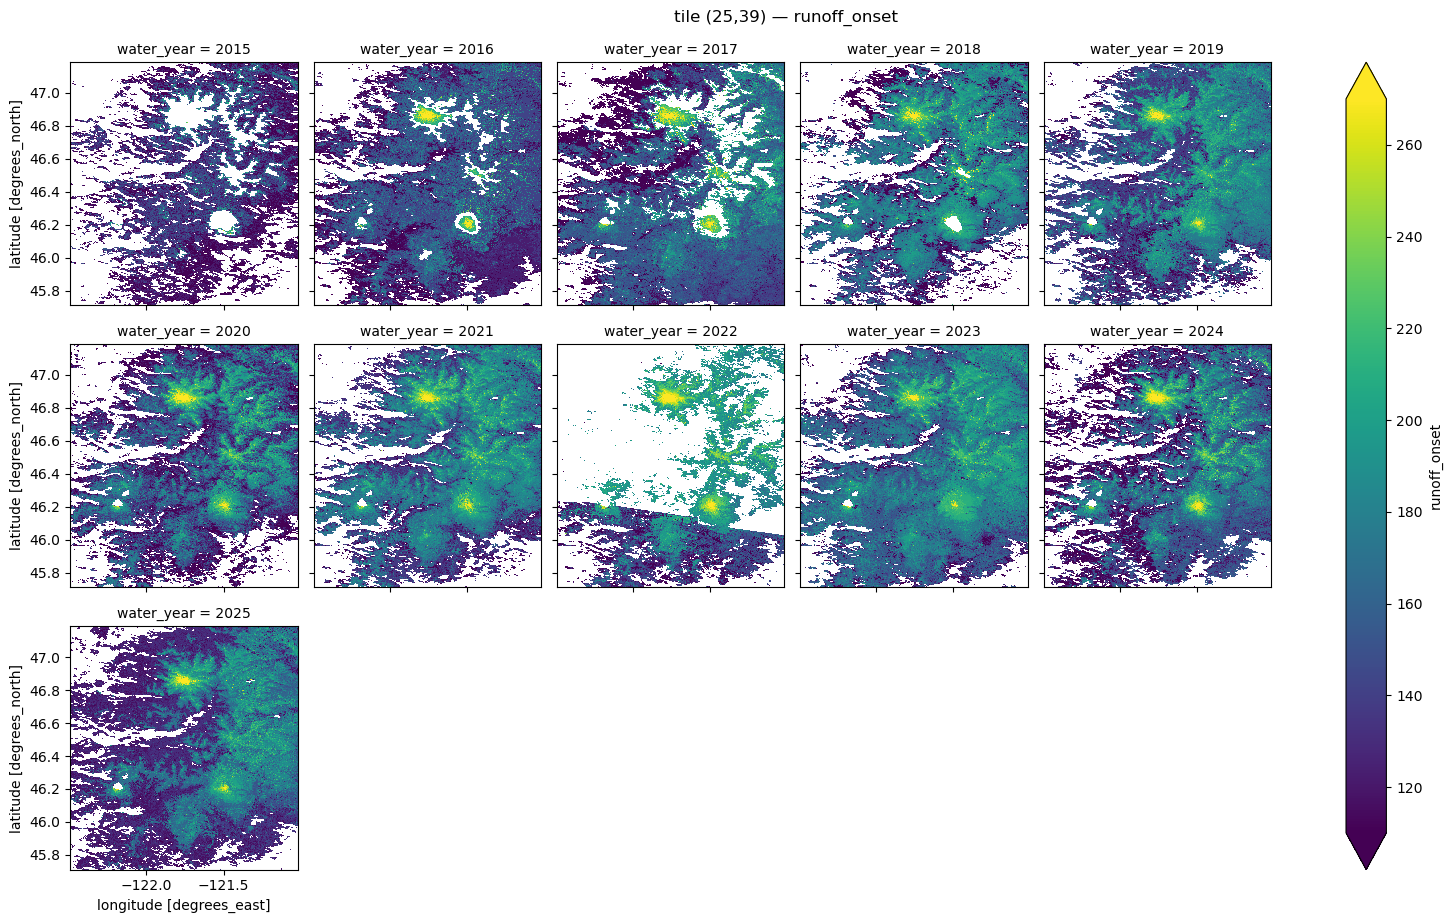

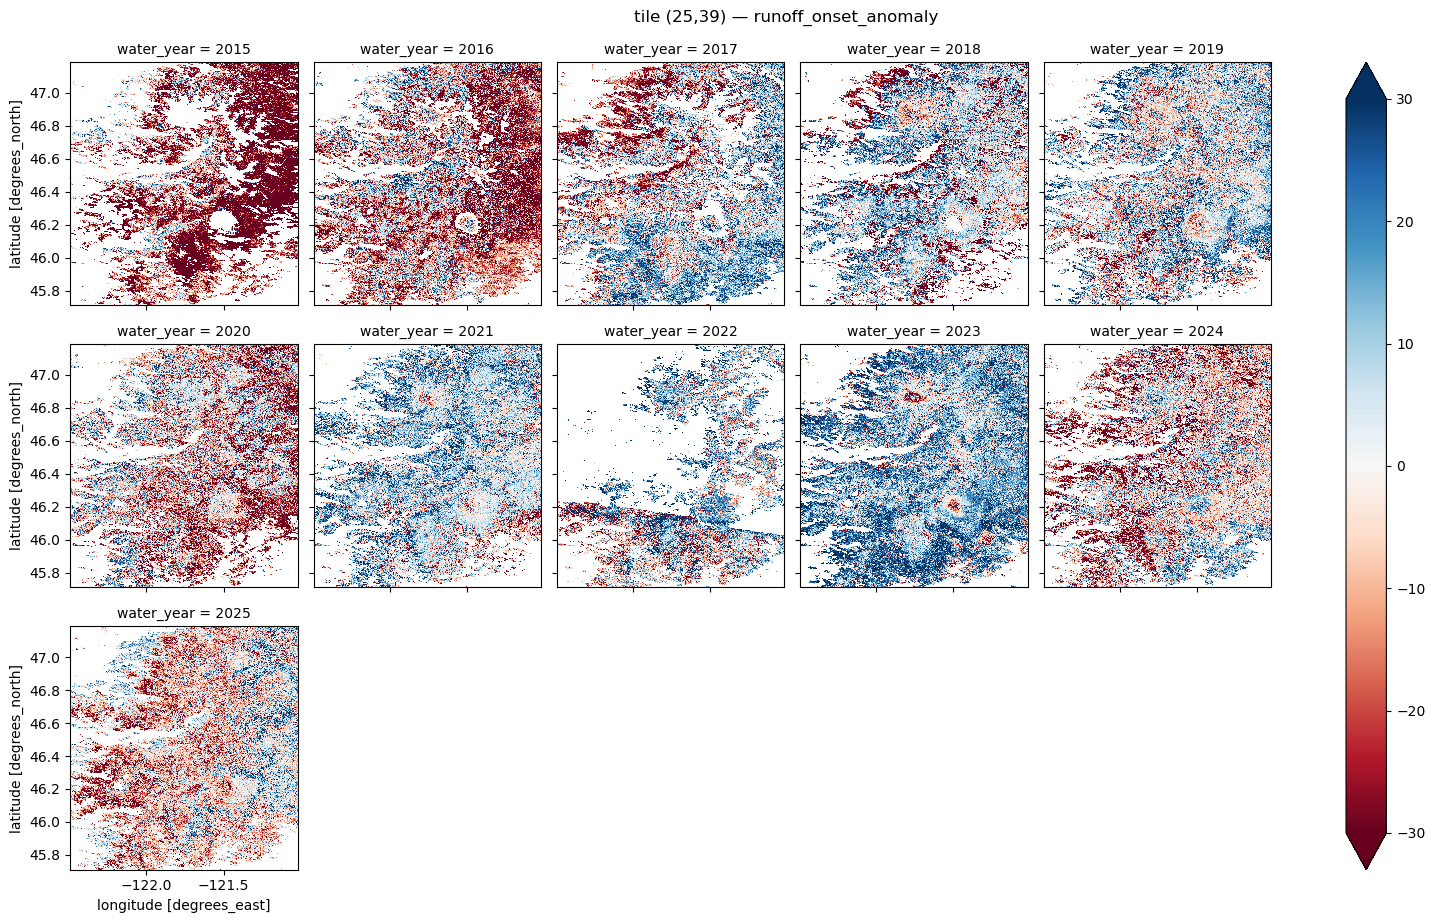

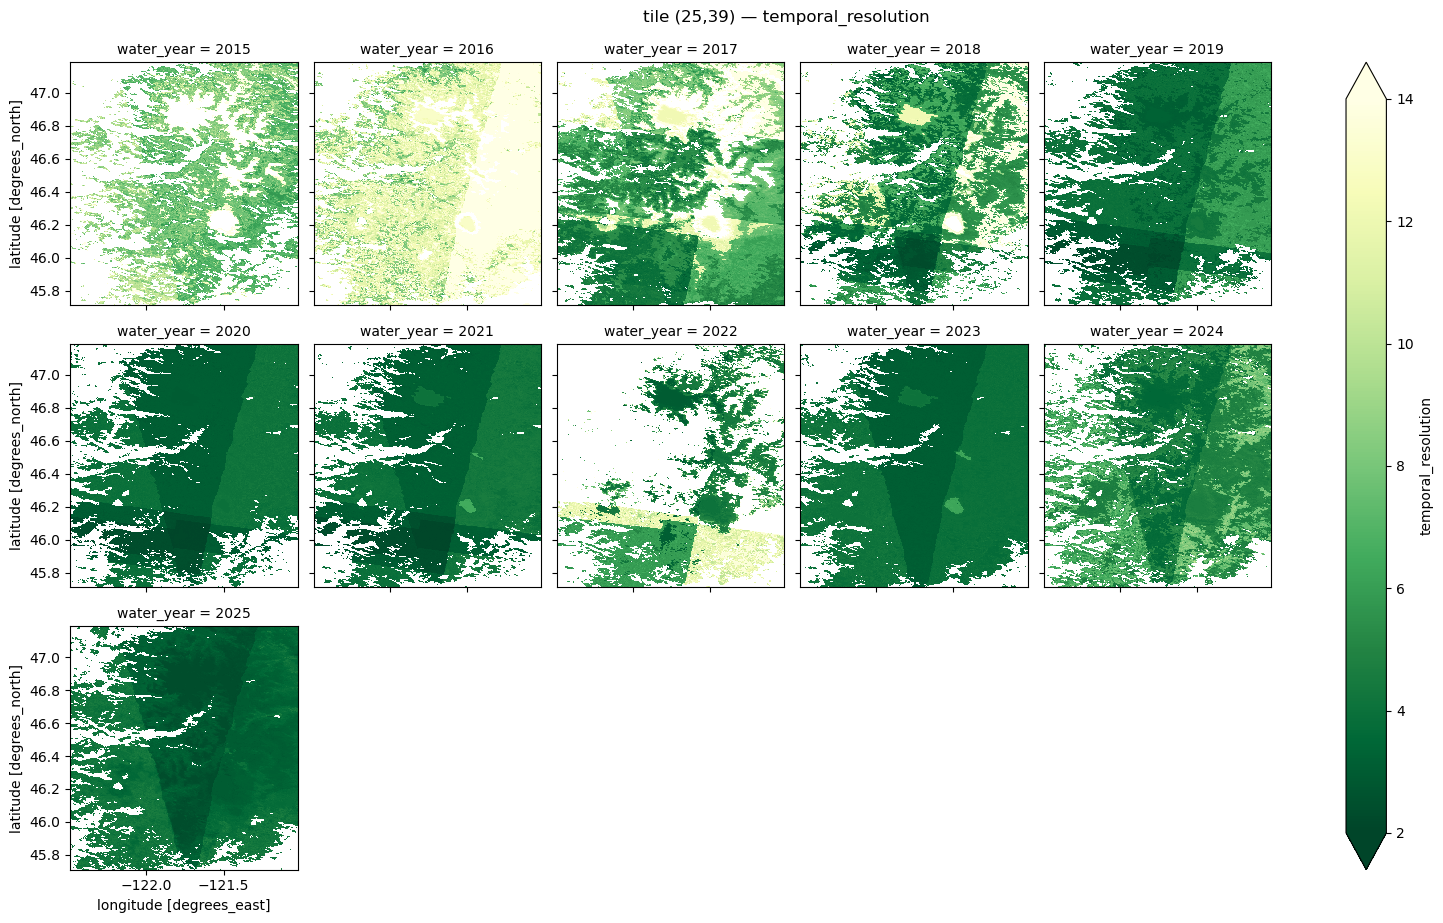

In [7]:
ds_decoded, _, _ = qc.open_release(config, mask_and_scale=True)
qc.view_tile(config, ds_decoded, 25, 39)   # Rainier

## Verdict

In [8]:
summary_df = qc.summarize({
    '1 schema': schema_df,
    '2 ledger vs data': ledger_df,
    '3 invariants': invariants_df,
    '4 composites': composites_df,
    '5 seams': seams_df,
    'fingerprint vs baseline': fingerprint_diff,
})
summary_df['n_tiles'] = len(TILES)
summary_df['source'] = source
display(summary_df)
print('\nOVERALL:', 'PASS' if (summary_df.verdict == 'PASS').all() else 'FAIL')

save_result_table(summary_df, 'qc_gates', version=config.version, results_dir='results')

,gate,checks,failed,verdict,n_tiles,source
0,1 schema,40,0,PASS,14,"tag v10.0, snapshot 5GXWVWYG3BG5XMFXNAH0"
1,2 ledger vs data,168,0,PASS,14,"tag v10.0, snapshot 5GXWVWYG3BG5XMFXNAH0"
2,3 invariants,84,0,PASS,14,"tag v10.0, snapshot 5GXWVWYG3BG5XMFXNAH0"
3,4 composites,42,0,PASS,14,"tag v10.0, snapshot 5GXWVWYG3BG5XMFXNAH0"
4,5 seams,28,0,PASS,14,"tag v10.0, snapshot 5GXWVWYG3BG5XMFXNAH0"
5,fingerprint vs baseline,96,0,PASS,14,"tag v10.0, snapshot 5GXWVWYG3BG5XMFXNAH0"



OVERALL: PASS
wrote 6 row(s) -> results/v10/qc_gates.csv


PosixPath('results/v10/qc_gates.csv')

## Appendix — v9 ↔ v10 (historical)

The v10 rebuild's acceptance check, kept runnable but off by default: v9 is frozen and v10 is
*expected* to differ from it, so this diff has no failing value and is documentation rather
than a gate. The full rubric is in [`README.md`](README.md) (*QC filter corrected in v10*);
the short version, for reading the table below:

1. **Coverage changes dominate.** v10 uses the `modis_snow_phenology_v1` mask, and the S1
   catalog gained scenes since the v9 run — several tile-years have data in v10 and none in v9.
2. **The QC filter was corrected in v10** (edge-anchored max-gap; `min_monthly_acquisitions`
   removed), so `pct_identical` tracks S1 acquisition redundancy rather than being uniformly
   high: ≈98–99.7% in truly dense years (WY2020/2021), but 7–65% with `med_absdiff` 1–11 d in
   sparse S1A-solo years — expected and correct.
3. **Read chunking changed** (2048 vs 512), which is deliberately not bit-reproducible:
   ~99.5% of pixels identical, ~0.4% flipping between near-tied backscatter minima.
4. **Never align the two stores by coordinate value.** The grids share a lattice, but the
   materialized `latitude` arrays differ by ~3e-14° (one float64 ULP), so `xr.align` fails
   while the grids are in fact identical. `tile_region_slices_on_grid` compares by integer
   index — v9 tile (r, c) is v10 tile (r + 2, c).

In [9]:
RUN_V9_COMPARISON = True

if RUN_V9_COMPARISON:
    import xarray as xr
    from global_snowmelt_runoff_onset import store as gsro_store

    ROW, COL = 25, 39   # v10 index (v9: 23,39)
    config_v9 = Config('config/global_config_v9.txt')
    ds_v9 = xr.open_zarr(config_v9.global_runoff_store, consolidated=True, chunks=None)
    ds_v10, _, _ = qc.open_release(config, mask_and_scale=True)

    region_v9 = gsro_store.tile_region_slices_on_grid(config, ROW, COL, config_v9)
    region_v10 = gsro_store.tile_region_slices(config, ROW, COL)
    years = sorted({int(wy) for wy in ds_v9.water_year.values}
                   & {int(wy) for wy in ds_v10.water_year.values})

    rows = []
    for wy in years:
        a = ds_v9.runoff_onset.sel(water_year=wy).isel(region_v9).values
        b = ds_v10.runoff_onset.sel(water_year=wy).isel(region_v10).values
        both = np.isfinite(a) & np.isfinite(b)
        d = np.abs(a[both] - b[both])
        rows.append({'water_year': wy, 'v9_px': int(np.isfinite(a).sum()),
                     'v10_px': int(np.isfinite(b).sum()), 'both_px': int(both.sum()),
                     'pct_identical': round(100 * float((d == 0).mean()), 1) if d.size else np.nan,
                     'med_absdiff_d': float(np.median(d)) if d.size else np.nan})
    display(pd.DataFrame(rows))

SAS token is valid until 2026-08-26 19:52 UTC (308.0 hours)
----------------------------------------
Configuration loaded:
config_name = global_config_v9
version = v9
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 81.099
bbox_bottom = -59.999
wy_start = 2015
wy_end = 2024
low_backscatter_threshold = 0.001
min_monthly_acquisitions = 1
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow.geojson
tile_results_path = processing/tile_data/tile_results_v9.csv
global_runoff_zarr_store_azure_path = snowmelt/snowmelt_runoff_onset/global_v9.zarr
seasonal_snow_mask_zarr_store_azure_path = snowmelt/snow_cover/global_modis_snow_cover.zarr
season

,water_year,v9_px,v10_px,both_px,pct_identical,med_absdiff_d
0,2015,1397183,2198012,1115786,16.5,11.0
1,2016,1571970,3211134,1437322,7.4,10.0
2,2017,3569784,3188775,3176538,10.8,7.0
3,2018,2746223,2728572,2727973,18.9,4.0
4,2019,3110305,3109162,3109162,49.6,1.0
5,2020,3072787,3072072,3072072,99.7,0.0
6,2021,3056094,3055366,3055365,98.3,0.0
7,2022,2448426,1678883,1678857,63.3,0.0
8,2023,3494682,3383071,3372625,25.9,2.0
9,2024,3126843,3125783,3125783,40.2,2.0
